This notebook contains the complete implementation of a neural network from scratch up to this stage, including:

- Dense Layer (`Layer_Dense`)
- ReLU Activation
- Softmax Activation
- Categorical Cross-Entropy Loss
- Combined Softmax Activation and Categorical Cross-Entropy Loss
- Forward Pass
- Backward Pass (Backpropagation)

The implementation has been tested on the Spiral dataset.

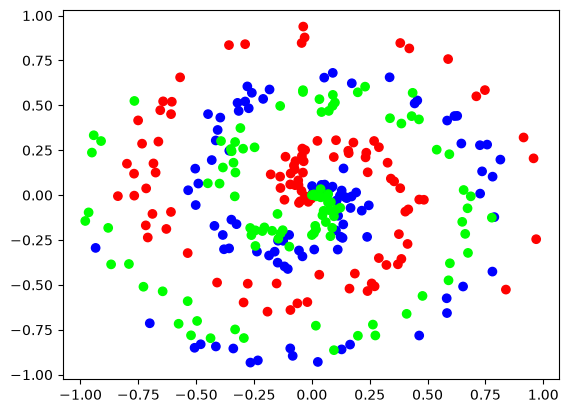

In [ ]:
#import packages
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()

#Dataset
import matplotlib.pyplot as plt
X,y=spiral_data(samples=100,classes=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='brg')
plt.show()

In [6]:
#Dense layer

class Layer_dense:
    #Layer intialization
    def __init__(self, n_inputs, n_neurons):
        #Intialize weights and biases
        self.weights=0.01*np.random.randn(n_inputs, n_neurons)
        self.biases=np.zeros((1,n_neurons))

    #Forward pass
    def forward(self, inputs):
        #remember input values
        self.inputs=inputs
        #Calculate output values from inputs, weights, biases
        self.output=np.dot(inputs, self.weights)+self.biases

    def backward(self, dvalues):
        #gradients on parameters
        self.dweights=np.dot(self.inputs.T, dvalues)
        self.dbiases=np.sum(dvalues, axis=0,keepdims=True)

        #gradient on values
        self.dinputs=np.dot(dvalues, self.weights.T)

In [21]:
# Relu activation 
class Activation_Relu:
    #forward pass
    def forward(self,inputs):
        #Calculate output values from input
        self.inputs=inputs
        self.output=np.maximum(0,inputs)

        #Backward pass

    def backward(self, dvalues):
        #since we need to modify the original variable 
        #Make a copy of the values first
        self.dinputs=dvalues.copy()
        self.dinputs[self.inputs <=0]=0


In [8]:
#Softmax activation

class Activation_Softmax:
    # Forward Pass
    def forward(self, inputs):
        #Get unnormalized probabilities
        exp_values=np.exp(inputs-np.max(inputs, axis=1, keepdims=True))
        #Normalize them for each sample
        probabilities=exp_values/np.sum(exp_values, axis=1, keepdims=True)
        self.output=probabilities

In [9]:
# Implementing the loss class

class Loss:
    # Calculates the data and regularization losses
    def calculate(self, output,y):
        #Calculate sample losses
        sample_losses=self.forward(output,y)
        #Calculate mean loss
        data_loss=np.mean(sample_losses)
        #return Loss
        return data_loss

#we implement the class loss just for the sake of simplicity
#So we can also see weight values

# Implemnting the categorical cross entropy class

class Loss_CategoricalCrossentropy(Loss):

    #Backward [ass
    def backward(self, dvalues, y_true):
        # Number of samples
        samples=len(dvalues)
        #number of labels in every sample
        labels=len(dvalues[0])
        # If labels are sparse, turn them into one-hot vector
        if len(y_true.shape)==1:
            y_true=np.eye(labels)[y_true]
        # calculate gradient
        self.dinputs=-y_true/dvalues
        #normalize gradient
        self.dinputs=self.dinputs/samples
    #forward pass 
    def forward(self,y_pred,y_true):
        samples=len(y_pred)
        #Clip data to prevent divisions by 0
        #Clip both sides to not drag mean towards any value
        y_pred_clipped=np.clip(y_pred, 1e-7,1-1e-7)
        if len(y_true.shape)==1:
            correct_confidences=y_pred_clipped[
                range(samples),
                y_true
            ]
            #Mask values -only for one-hot encoded labels
        elif len(y_true.shape)==2:
            correct_confidences = np.sum(
                y_pred_clipped*y_true,
                axis=1
            )
        #losses
        negative_log_likelihoods=-np.log(correct_confidences)
        return negative_log_likelihoods


Combined Softmax activation and categorical cross entropy for last layer: Forward and backward pass

In [10]:
class Activation_Softmax_Loss_categoricalCrossentropy:
    #creates activation and loss function objects
    def __init__(self):
        self.activation=Activation_Softmax()
        self.loss=Loss_CategoricalCrossentropy()

    #forward pass
    def forward(self, inputs, y_true):
        #Output layer's activation function
        self.activation.forward(inputs)
        # Set the output
        self.output=self.activation.output
        # Calculate and return loss values
        return self.loss.calculate(self.output, y_true)
    
        #Backward pass
    def backward(self, dvalues, y_true):
        samples=len(dvalues)
        if len(y_true.shape)==2:
            y_true=np.argmax(y_true, axis=1)
        self.dinputs=dvalues.copy()
        #calculate the gradient
        self.dinputs[range(samples), y_true]-=1
        #Normalize gradient
        self.dinputs=self.dinputs/samples



Full code upto this point: Forward and backward pass

In [22]:
X,y=spiral_data(samples=100, classes=3)
#Create Dense layer with 2 input features and 3 output values
dense1=Layer_dense(2,3)
activation1=Activation_Relu()
#Create second dense layer with 3 inputs and 3 output values
dense2=Layer_dense(3,3)

#Create softmax classifiers combined loss and activation
loss_activation=Activation_Softmax_Loss_categoricalCrossentropy()
dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
#takes the output of second dense layer and returns loss
loss=loss_activation.forward(dense2.output, y)

print(loss_activation.output[:5])
print('loss:',loss)

#Calculate accuracy from output of activation2 and targets
predictions=np.argmax(loss_activation.output,axis=1)
if len(y.shape)==2:
    y=np.argmax(y, axis=1)
accuracy=np.mean(predictions==y)
print("acc:", accuracy)

#Backward pass

loss_activation.backward(loss_activation.output, y)
dense2.backward(loss_activation.dinputs)
activation1.backward(dense2.dinputs)
dense1.backward(activation1.dinputs)

#print gradients

print(dense1.dweights)
print(dense1.dbiases)

print(dense2.dweights)
print(dense2.dbiases)




[[0.33333334 0.33333334 0.33333334]
 [0.3333336  0.33333313 0.33333328]
 [0.33333242 0.3333339  0.33333364]
 [0.33333197 0.33333424 0.33333382]
 [0.3333343  0.33333254 0.33333316]]
loss: 1.0986075
acc: 0.4066666666666667
[[-2.6232953e-04  8.2318606e-05  4.2048570e-05]
 [ 3.7354979e-04 -5.6071756e-05  4.2183332e-05]]
[[-5.7615567e-04 -2.1818290e-04  8.1951421e-06]]
[[-8.8249893e-05  3.9109756e-05  4.9140126e-05]
 [ 3.4921707e-04 -4.5799618e-04  1.0877908e-04]
 [ 1.5011428e-04 -2.1802635e-04  6.7912049e-05]]
[[-1.2021046e-06 -5.6461431e-08  1.1466909e-06]]
